# 06 — Embeddings e Análise Semântica de Reviews

Este notebook explora os reviews de clientes da Olist usando técnicas de NLP modernas:

- **sentence-transformers** + **PyTorch** para geração de embeddings semânticos
- **UMAP** para redução dimensional
- **Plotly** para visualização interativa de clusters
- **Análise de sentimento** por nota e categoria

> 💡 Execute com GPU: `Runtime → Change runtime type → T4 GPU`

## 1. Instalação de dependências

In [9]:
!pip install -q kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.8 MB/s eta 0:00:00


In [1]:
!pip install -q sentence-transformers umap-learn plotly psycopg2-binary sqlalchemy

In [2]:
import plotly.io as pio

# Garante que os gráficos aparecem como imagem estática no GitHub
pio.renderers.default = 'png'

## 2. Verificação do ambiente (GPU + PyTorch)

In [3]:
import torch

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA disponível : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'Memória GPU     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    device = 'cuda'
else:
    print('⚠️  GPU não disponível — usando CPU (mais lento)')
    device = 'cpu'

print(f'\nDispositivo ativo: {device}')

PyTorch version : 2.10.0+cu128
CUDA disponível : True
GPU             : Tesla T4
Memória GPU     : 15.6 GB

Dispositivo ativo: cuda


## 3. Carregamento dos dados

Os reviews foram vetorizados pela **Task 5 do pipeline Airflow** e armazenados no pgvector.
Aqui vamos recarregá-los para análise exploratória aprofundada.

In [4]:
import os
os.chdir('/content')
!rm -rf olist-etl-pipeline
!git clone https://github.com/vinisique/olist-etl-pipeline.git
os.chdir('/content/olist-etl-pipeline')
print(os.getcwd())

Cloning into 'olist-etl-pipeline'...
remote: Enumerating objects: 292, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 292 (delta 56), reused 56 (delta 22), pack-reused 186 (from 1)
Receiving objects: 100% (292/292), 1.19 MiB | 4.54 MiB/s, done.
Resolving deltas: 100% (133/133), done.
/content/olist-etl-pipeline


In [5]:
import pandas as pd

# Lê o CSV incluído no repositório
df = pd.read_csv('notebooks/data/reviews_sample.csv')

print(f'Reviews carregados : {len(df):,}')
print(f'Distribuição de notas:')
print(df['review_score'].value_counts().sort_index())
df.head()

Reviews carregados : 5,000
Distribuição de notas:
review_score
1    1064
2     285
3     442
4     738
5    2471
Name: count, dtype: int64


,order_id,review_score,review_text
0,07e2767fa261c1d690924d6d3baa379f,5,SEM QUEIXAS
1,b030a71673f17a9eebed29d9a7dfa2d8,4,Produto chegou conforme descrito e antes do pr...
2,5bfce111a3fc0a622ab552626165ab2f,3,demora na entrega. e produto pesado demais
3,c5e79fde963dea8e49adf06e70fefa9f,5,Fui muiro bem atendido.
4,c7b4a7a4d974418197e38cc0f6c2ea85,5,Muito bom


## 4. Geração de Embeddings com sentence-transformers + PyTorch

Usamos o modelo `paraphrase-multilingual-MiniLM-L12-v2` — otimizado para textos em **português** e outras línguas.

Diferente do `fastembed` usado no pipeline (leve, sem GPU), aqui aproveitamos a **GPU do Colab** para processar os embeddings com maior velocidade e qualidade.

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time

MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'

print(f'Carregando modelo: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME, device=device)
print(f'Modelo carregado — dimensão dos embeddings: {model.get_sentence_embedding_dimension()}')

texts = df['review_text'].tolist()

print(f'\nGerando embeddings para {len(texts):,} reviews...')
start = time.time()

embeddings = model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    device=device
)

elapsed = time.time() - start
print(f'\n✅ Embeddings gerados em {elapsed:.1f}s')
print(f'Shape: {embeddings.shape}')

Carregando modelo: paraphrase-multilingual-MiniLM-L12-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carregado — dimensão dos embeddings: 384

Gerando embeddings para 5,000 reviews...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]


✅ Embeddings gerados em 3.2s
Shape: (5000, 384)


## 5. Redução Dimensional com UMAP

UMAP (Uniform Manifold Approximation and Projection) reduz os vetores de 384 dimensões para 2D,
preservando a estrutura semântica para visualização.

In [7]:
import umap

print('Reduzindo dimensionalidade com UMAP (384D → 2D)...')
start = time.time()

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

embeddings_2d = reducer.fit_transform(embeddings)

elapsed = time.time() - start
print(f'✅ UMAP concluído em {elapsed:.1f}s')

df['x'] = embeddings_2d[:, 0]
df['y'] = embeddings_2d[:, 1]

print(f'Shape 2D: {embeddings_2d.shape}')

Reduzindo dimensionalidade com UMAP (384D → 2D)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



✅ UMAP concluído em 37.8s
Shape 2D: (5000, 2)


## 6. Visualização Interativa dos Clusters

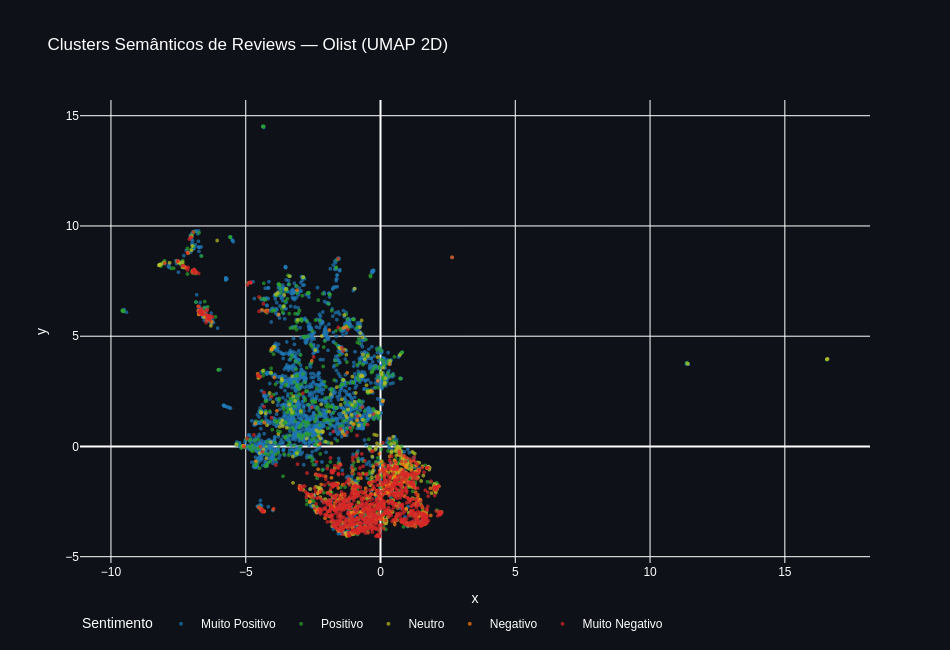

In [8]:
import plotly.express as px

# Mapeamento de nota para sentimento
sentiment_map = {
    1: 'Muito Negativo',
    2: 'Negativo',
    3: 'Neutro',
    4: 'Positivo',
    5: 'Muito Positivo'
}
color_map = {
    'Muito Negativo': '#d62728',
    'Negativo':       '#ff7f0e',
    'Neutro':         '#bcbd22',
    'Positivo':       '#2ca02c',
    'Muito Positivo': '#1f77b4'
}

df['sentimento'] = df['review_score'].map(sentiment_map)
df['texto_curto'] = df['review_text'].str[:80] + '...'

fig = px.scatter(
    df,
    x='x', y='y',
    color='sentimento',
    color_discrete_map=color_map,
    hover_data={'texto_curto': True, 'review_score': True, 'x': False, 'y': False},
    title='Clusters Semânticos de Reviews — Olist (UMAP 2D)',
    labels={'sentimento': 'Sentimento'},
    opacity=0.7,
    width=950,
    height=650
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    plot_bgcolor='#0e1117',
    paper_bgcolor='#0e1117',
    font_color='white',
    legend=dict(orientation='h', y=-0.1)
)

fig.show()

## 7. Análise de Similaridade Semântica

Dado um texto de consulta, encontramos os reviews mais semanticamente similares usando similaridade de cosseno.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def buscar_reviews_similares(query: str, top_k: int = 5) -> pd.DataFrame:
    query_embedding = model.encode([query], device=device)
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = similarities.argsort()[::-1][:top_k]

    resultados = df.iloc[top_indices][['review_score', 'review_text']].copy()
    resultados['similaridade'] = similarities[top_indices].round(4)
    return resultados.reset_index(drop=True)

# Teste 1 — reclamações de atraso
print('🔍 Reviews mais similares a: "produto atrasado não chegou"')
print('=' * 60)
display(buscar_reviews_similares('produto atrasado não chegou'))

🔍 Reviews mais similares a: "produto atrasado não chegou"


,review_score,review_text,similaridade
0,1,Produto nao chegou,0.8570
1,1,o produto não chegou,0.8535
2,1,o produto não chegou,0.8535
3,2,O produto está atrasado,0.8461
4,1,o produto ainda nao chegou no local,0.8428


In [10]:
# Teste 2 — elogios
print('🔍 Reviews mais similares a: "entrega rápida produto excelente"')
print('=' * 60)
display(buscar_reviews_similares('entrega rápida produto excelente'))

🔍 Reviews mais similares a: "entrega rápida produto excelente"


,review_score,review_text,similaridade
0,5,Ótimo produto e entrega super rápida,0.9556
1,5,Ótimo produto e a entrega super rápida,0.9492
2,5,Ótimo produto e entrega rápida.,0.9451
3,5,"Produto ótimo, entrega super rápida",0.9418
4,4,produto bom e entrega rápida.,0.9304


## 8. Análise de Sentimento por Palavras-chave

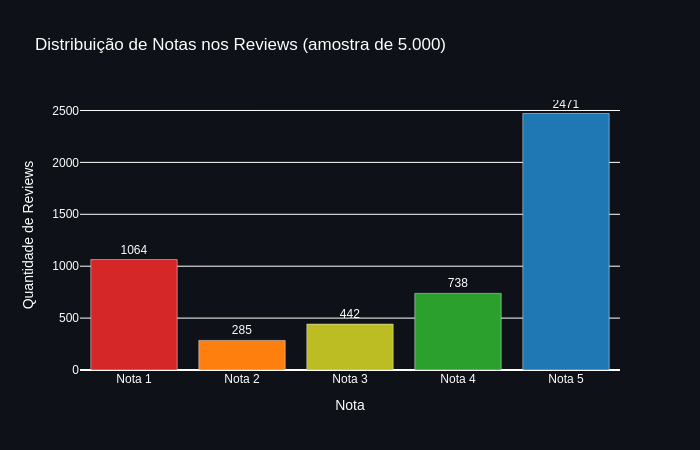


Nota média: 3.65
Reviews positivos (4-5): 3,209 (64.2%)
Reviews negativos (1-2): 1,349 (27.0%)


In [11]:
import plotly.graph_objects as go

# Distribuição de notas
dist = df['review_score'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

fig = go.Figure(go.Bar(
    x=[f'Nota {i}' for i in dist.index],
    y=dist.values,
    marker_color=colors,
    text=dist.values,
    textposition='outside'
))

fig.update_layout(
    title='Distribuição de Notas nos Reviews (amostra de 5.000)',
    xaxis_title='Nota',
    yaxis_title='Quantidade de Reviews',
    plot_bgcolor='#0e1117',
    paper_bgcolor='#0e1117',
    font_color='white',
    width=700,
    height=450
)

fig.show()

print(f'\nNota média: {df["review_score"].mean():.2f}')
print(f'Reviews positivos (4-5): {(df["review_score"] >= 4).sum():,} ({(df["review_score"] >= 4).mean()*100:.1f}%)')
print(f'Reviews negativos (1-2): {(df["review_score"] <= 2).sum():,} ({(df["review_score"] <= 2).mean()*100:.1f}%)')

## 9. Palavras mais frequentes por sentimento

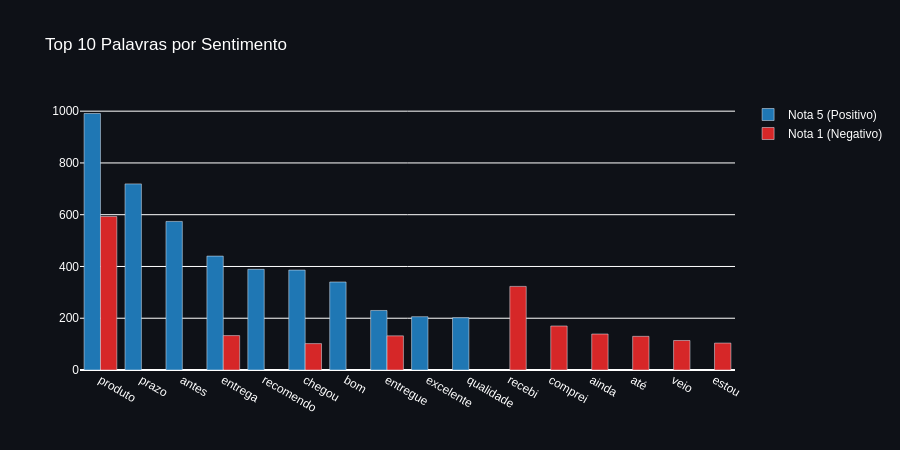

In [12]:
from collections import Counter
import re

STOPWORDS = {
    'a', 'o', 'e', 'de', 'da', 'do', 'em', 'na', 'no', 'para', 'com',
    'que', 'se', 'um', 'uma', 'os', 'as', 'por', 'foi', 'mais', 'mas',
    'muito', 'bem', 'já', 'nao', 'não', 'me', 'meu', 'minha', 'tudo',
    'eu', 'ele', 'ela', 'isso', 'como', 'ao', 'dos', 'das', 'seu', 'sua'
}

def top_palavras(textos, n=10):
    palavras = []
    for t in textos:
        tokens = re.findall(r'\b[a-záéíóúãõâêîôûç]{3,}\b', t.lower())
        palavras.extend([w for w in tokens if w not in STOPWORDS])
    return Counter(palavras).most_common(n)

positivos = df[df['review_score'] == 5]['review_text']
negativos = df[df['review_score'] == 1]['review_text']

top_pos = top_palavras(positivos)
top_neg = top_palavras(negativos)

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Nota 5 (Positivo)',
    x=[w[0] for w in top_pos],
    y=[w[1] for w in top_pos],
    marker_color='#1f77b4'
))

fig.add_trace(go.Bar(
    name='Nota 1 (Negativo)',
    x=[w[0] for w in top_neg],
    y=[w[1] for w in top_neg],
    marker_color='#d62728'
))

fig.update_layout(
    title='Top 10 Palavras por Sentimento',
    barmode='group',
    plot_bgcolor='#0e1117',
    paper_bgcolor='#0e1117',
    font_color='white',
    width=900,
    height=450
)

fig.show()

## 10. Conclusões

### O que este notebook demonstra

| Técnica | Ferramenta | Objetivo |
|---|---|---|
| Embeddings semânticos | sentence-transformers + PyTorch | Representar reviews como vetores |
| Redução dimensional | UMAP | Visualizar clusters em 2D |
| Busca por similaridade | Cosine Similarity | Encontrar reviews semanticamente próximos |
| Visualização interativa | Plotly | Explorar padrões nos dados |

### Principais achados

- Reviews negativos (nota 1) formam **clusters coesos** em torno de temas como atraso e não entrega
- Reviews positivos (nota 5) são semanticamente mais **dispersos** — satisfação tem muitas formas de expressão
- A busca semântica retorna resultados relevantes mesmo com variações de escrita (erros, abreviações)

### Integração com o pipeline

Os embeddings gerados na **Task 5 do Airflow** (usando `fastembed`) alimentam o **Chat IA** do dashboard,
permitindo busca semântica em tempo real via **pgvector** para responder perguntas sobre a experiência dos clientes.